In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("weight-height.csv")

In [35]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [36]:
df.shape

(10000, 3)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


C:\Users\kumar\AppData\Local\Temp\ipykernel_10008\3470658916.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Height"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_10008\3470658916.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Weight"])


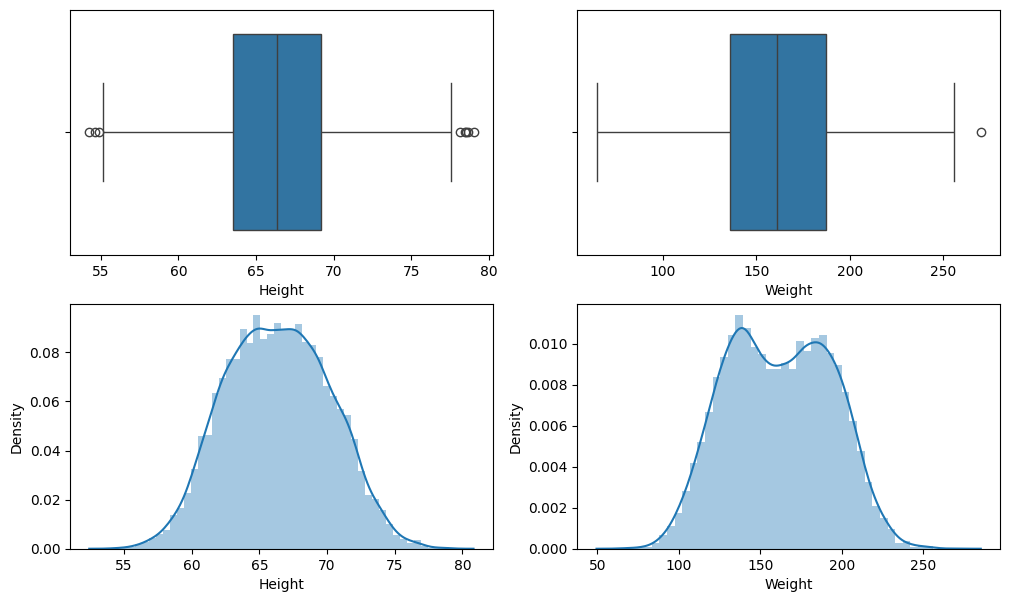

In [38]:
plt.figure(figsize=(12,7))

plt.subplot(221)
sns.boxplot(df, x = df["Height"])

plt.subplot(222)
sns.boxplot(df, x = df["Weight"])

plt.subplot(223)
sns.distplot(df["Height"])

plt.subplot(224)
sns.distplot(df["Weight"])

plt.show()

In [39]:
# We will work on the Height column because there are more outliers

In [40]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [11]:
upper_limit = df["Height"].quantile(0.99)
upper_limit

74.7857900583366

In [12]:
lower_limit = df["Height"].quantile(0.01)
lower_limit

58.13441158671655

In [17]:
df[(df["Height"] >= upper_limit) | (df["Height"] <= lower_limit)] # >> outliers

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# Trimming

In [20]:
new_df = df[(df["Height"] <= upper_limit) & (df["Height"] >= lower_limit)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [42]:
new_df["Height"].describe(), df["Height"].describe()

(count    9800.000000
 mean       66.364366
 std         3.645075
 min        58.134496
 25%        63.577162
 50%        66.318070
 75%        69.119896
 max        74.785714
 Name: Height, dtype: float64,
 count    10000.000000
 mean        66.367560
 std          3.847528
 min         54.263133
 25%         63.505620
 50%         66.318070
 75%         69.174262
 max         78.998742
 Name: Height, dtype: float64)

C:\Users\kumar\AppData\Local\Temp\ipykernel_10008\2423354611.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["Height"])


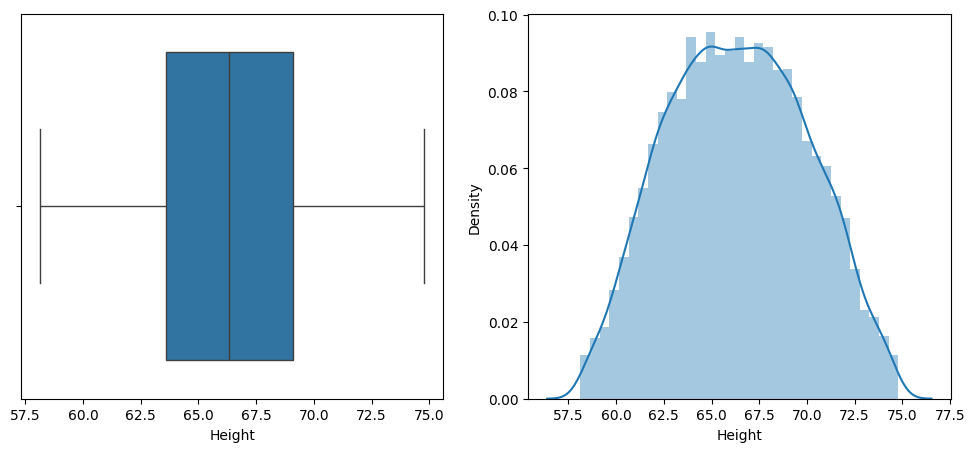

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.boxplot(new_df, x = new_df["Height"])

plt.subplot(122)
sns.distplot(new_df["Height"])

plt.show()

In [44]:
# As we can see there is not outliers in the above height column 

# Capping >> Winsorization

In [45]:
# When we use Capping in percentile method then it is also called Winsorization

In [46]:
upper_limit, lower_limit

(74.7857900583366, 58.13441158671655)

In [47]:
df["Height"] = np.where(df["Height"] >= upper_limit, upper_limit,
        np.where(df["Height"] <= lower_limit, lower_limit, df["Height"]))

In [48]:
df.shape

(10000, 3)

In [49]:
df["Height"].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\kumar\AppData\Local\Temp\ipykernel_10008\1478170480.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Height"])


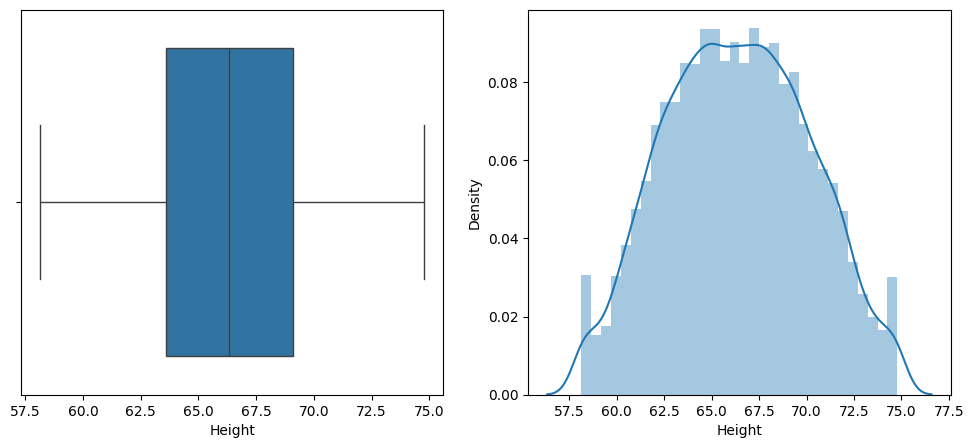

In [50]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.boxplot(df, x = new_df["Height"])

plt.subplot(122)
sns.distplot(df["Height"])

plt.show()